In [ ]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

# Trabalho 1 — Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



In [6]:
! ls

assignment1_outputs  classificacao_com_cnn.ipynb  data	teste.py


In [2]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path

import torch
import torchvision
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torch import nn
# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "tom0204"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

ModuleNotFoundError: No module named 'torch'

## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [ ]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:

#image_size = 224
#batch_size = 64

# Escreva seu código aqui

# note que o dataset já foi importado na célula acima
image_size = 224
batch_size = 64

"""
Definindo transformações
"""

my_transforms = transforms.Compose([
transforms.Resize((image_size,image_size)), # padronizando tamanho das imagens
transforms.ToTensor(), # números entre 0 e 1
transforms.Normalize(mean=[0.485,0.456,0.426], std=[0.229,0.224,0.225]) # normalizando
])

"""
Carregar conjuntos
"""

trainval_dataset = OxfordIIITPet(
    root = './data', 
    download = True, 
    transform = my_transforms, 
    split = "trainval"
)
test_dataset =  OxfordIIITPet(
    root = './data', 
    download = True, 
    transform = my_transforms, 
    split = "test"
)

"""
Split treino/validação
"""

len_train = int(len(trainval_dataset)*0.8)
len_val = len(trainval_dataset) - len_train

generator = torch.Generator().manual_seed(seed)
train_dataset, val_dataset = random_split(trainval_dataset, [len_train, len_val], generator = generator)

"""
Criando dataloaders
"""

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True, generator = generator)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False, generator = generator)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle= False, generator = generator)

### Resposta 1.3

Explique brevemente como você construiu o split de treino, validação e teste.


## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

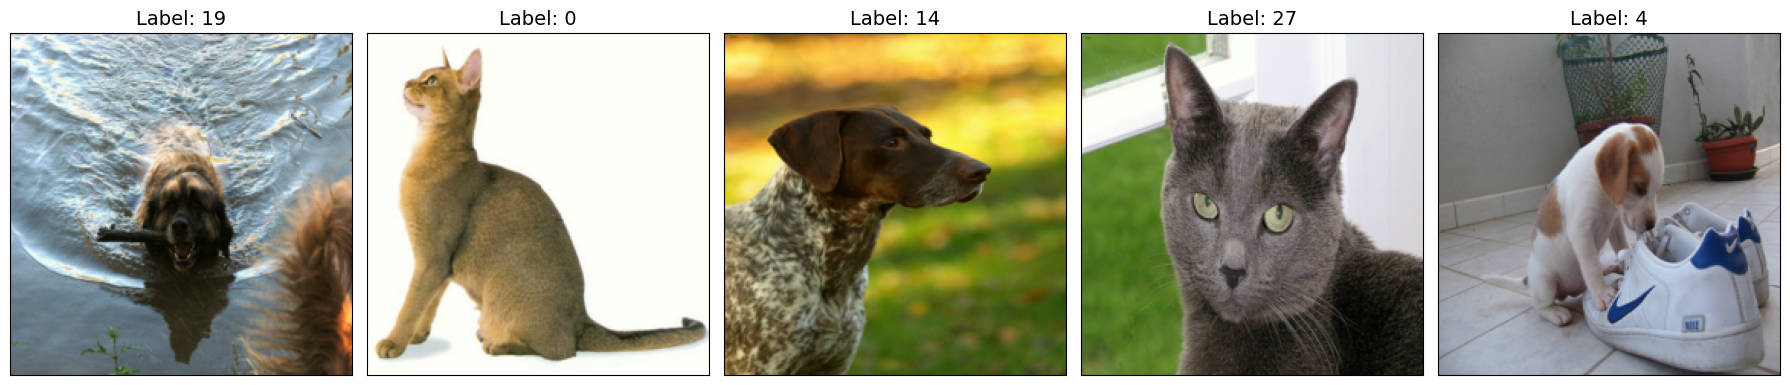

class_names: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
#class_names: 37
counts(dict): Counter({3: 87, 6: 86, 4: 85, 13: 85, 14: 84, 15: 84, 21: 84, 2: 83, 36: 83, 24: 83, 0: 82, 16: 82, 31: 81, 25: 81, 23: 81, 32: 81, 9: 80, 35: 80, 7: 80, 30: 79, 5: 79, 27: 78, 33: 78, 8: 78, 28: 78, 1: 78, 26: 77, 29: 77, 12: 77, 10: 77, 20: 76, 34: 76, 19: 75, 18: 75, 22: 73, 17: 71, 11: 70})
maior frequência: 87
menor frequência: 70


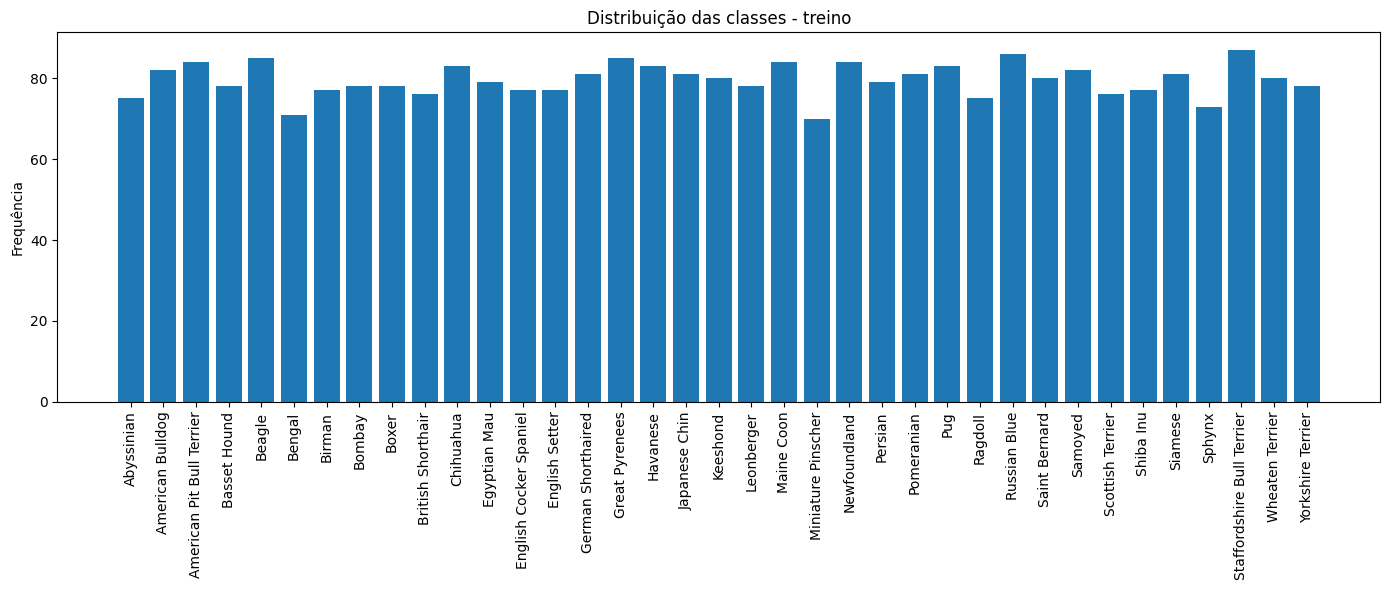

In [ ]:
# TODO:
# - mostrar algumas imagens do treino
# - obter nomes/classes
# - contar frequência por classe
# - fazer um gráfico simples

import matplotlib.pyplot as plt
from collections import Counter
import torchvision.transforms.functional as F

"""
Imagens de treino
"""
def show(imgs, labels):
#função tirada e modificada da documentação do pytorch https://docs.pytorch.org/vision/main/auto_examples/others/plot_visualization_utils.html
    fig, axs = plt.subplots(ncols=len(imgs), figsize=(18, 5), squeeze=False)
    # para visualizar vamos desnomalizar as imagens
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i, (img, label) in enumerate(zip(imgs, labels)):
        img = img.detach()
        img_desnorm = img*std + mean
        img_desnorm = torch.clamp(img_desnorm, 0, 1) #alguns pontos pretos estavam ficando azuis. Essa função limita of valores para o intervalo [0,1]
        img_desnorm = F.to_pil_image(img_desnorm)

        axs[0, i].imshow(np.asarray(img_desnorm))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
        axs[0, i].set_title(f"Label: {label}", fontsize=14)
        
    plt.tight_layout()
    plt.show()

img_list = [ train_dataset[i][0] for i in range(5)]
label_list = [ train_dataset[i][1] for i in range(5)]

show(img_list, label_list)

"""
nomes/classes
"""
class_names = trainval_dataset.classes # atributo nativo dos datasets do torchvision.datasets

print(f'class_names: {class_names}')
print(f'#class_names: {len(class_names)}')

"""
frequência por classe
"""
counts = Counter([trainval_dataset._labels[i] for i in train_dataset.indices])

print(f"counts(dict): {counts}")
print(f"maior frequência: {max(counts.values())}")
print(f"menor frequência: {min(counts.values())}")

"""
plot
"""


plt.figure(figsize=(14,6))
plt.bar(class_names, counts.values())
plt.xticks(rotation=90)
plt.ylabel("Frequência")
plt.title("Distribuição das classes - treino")
plt.tight_layout()
plt.show()



### Resposta 2.4–2.5

Todas as classes apresentam entre 70 e 87 amostras

Dificuldade: as imagens não têm o mesmo tamanho

## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [ ]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() # transforma a entrada (imagem) em um tensor 1-dimensional (achata a entrada)
        self.network = nn.Sequential(
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,37),
        )
    def forward(self,x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits
    
model_fnn = SimpleFNN() # instância para o modelo
print(model_fnn)



SimpleFNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=150528, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=37, bias=True)
  )
)


## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


In [ ]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     ...
#            nn.Linear(
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     ...
#
# def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
#     ...

# Escreva seu código aqui

def train_one_epoch(model, loader, optmizer, criterion, device):
    model.train()
    for batch, (X,y) in enumerate(loader):
        X,y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred,y)

        optmizer.zero_grad()
        loss.backward()
        optmizer.step()

    if (batch%100 == 0): print(f'loss: {loss:>7}')

def evaluate(model, loader, criterion, device):
    model.eval()
    size = len(loader.dataset)
    num_batches = len(loader)
    test_loss, correct = 0,0

    with torch.no_grad():
        for X,y in loader:
            X,y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += criterion(pred,y).item()
            correct += (pred.argmax(1)==y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct = correct/size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

def fit(model, train_loader, val_loader, optmizer, criterion, device, epochs, scheduler=None):
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train_one_epoch(model, train_loader, optmizer, criterion, device)
        evaluate(model, val_loader, criterion, device)

## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.

**Sugestão.**
Registre as escolhas de hiperparâmetros em uma célula ou tabela.


In [ ]:
# TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui

# device definido na primeira célula
learning_rate = 1e-3
epochs = 10
model_fnn = model_fnn.to(device)

criterion = nn.CrossEntropyLoss()
optmizer = torch.optim.Adam(model_fnn.parameters(), learning_rate)

fit(model_fnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 3.9%, Avg loss: 3.621108 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 4.9%, Avg loss: 3.598929 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 4.8%, Avg loss: 3.645070 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 5.7%, Avg loss: 3.677467 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 6.0%, Avg loss: 3.782835 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 5.7%, Avg loss: 3.719739 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 7.3%, Avg loss: 3.882902 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 5.4%, Avg loss: 3.852626 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 9.5%, Avg loss: 3.915824 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 6.2%, Avg loss: 4.352938 



### Resposta 5.6

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?


## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


In [ ]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv

        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(128*7*7 , 128)
        self.fcrelu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 37) 
        
    def forward(self, x):
        x = self.bnorm0(x)
        x = self.relu1(self.bnorm1(self.conv1(x)))
        x = self.pool12(self.relu12(self.bnorm12(self.conv12(x))))

        x = self.relu2(self.bnorm2(self.conv2(x)))
        x = self.pool22(self.relu22(self.bnorm22(self.conv22(x))))

        x = self.relu3(self.bnorm3(self.conv3(x)))
        x = self.pool32(self.relu32(self.bnorm32(self.conv32(x))))

        x = self.relu4(self.bnorm4(self.conv4(x)))
        x = self.pool42(self.relu42(self.bnorm42(self.conv42(x))))

        x = self.relu5(self.bnorm5(self.conv5(x)))
        x = self.pool52(self.relu52(self.bnorm52(self.conv52(x))))
        
        x = self.flatten(x)
        
        x = self.fcrelu1(self.fc1(x))
        logits = self.fc2(x)
        
        return logits

model_simplecnn = SimpleCNN()

learning_rate = 1e-3
epochs = 50
model_simplecnn = model_simplecnn.to(device)

criterion = nn.CrossEntropyLoss()
optmizer = torch.optim.Adam(model_simplecnn.parameters(), learning_rate)

fit(model_simplecnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 2.9%, Avg loss: 3.610495 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 3.7%, Avg loss: 3.599865 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 3.5%, Avg loss: 3.604329 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 4.9%, Avg loss: 3.597279 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 4.1%, Avg loss: 3.596142 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 4.6%, Avg loss: 3.522535 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 4.3%, Avg loss: 3.536997 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 4.5%, Avg loss: 3.667450 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 7.3%, Avg loss: 3.461588 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 7.7%, Avg loss: 3.401457 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 7.2%, Avg loss: 3.500139

### Resposta 6.3

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?


## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Data Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


In [ ]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final

import copy

"""
Rede profunda
"""



"""
BatchNorms
"""

class BatchCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.bnorm0 = nn.BatchNorm2d(3)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.conv12 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bnorm12 = nn.BatchNorm2d(32) 
        self.relu12 = nn.ReLU()
        self.pool12 = nn.MaxPool2d(kernel_size=2) 
        
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bnorm2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.conv22 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bnorm22 = nn.BatchNorm2d(64)
        self.relu22 = nn.ReLU()
        self.pool22 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bnorm3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.conv32 = nn.Conv2d(64, 96, kernel_size=3, padding=1)
        self.bnorm32 = nn.BatchNorm2d(96)
        self.relu32 = nn.ReLU()
        self.pool32 = nn.MaxPool2d(kernel_size=2)

    
        self.conv4 = nn.Conv2d(96, 96, kernel_size=3, padding=1)
        self.bnorm4 = nn.BatchNorm2d(96)
        self.relu4 = nn.ReLU()
        self.conv42 = nn.Conv2d(96, 128, kernel_size=3, padding=1)
        self.bnorm42 = nn.BatchNorm2d(128)
        self.relu42 = nn.ReLU()
        self.pool42 = nn.MaxPool2d(kernel_size=2)

        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bnorm5 = nn.BatchNorm2d(128)
        self.relu5 = nn.ReLU()
        self.conv52 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bnorm52 = nn.BatchNorm2d(128)
        self.relu52 = nn.ReLU()
        self.pool52 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(128*7*7 , 128)
        self.fcrelu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 37) 
        
    def forward(self, x):
        x = self.bnorm0(x)
        x = self.relu1(self.bnorm1(self.conv1(x)))
        x = self.pool12(self.relu12(self.bnorm12(self.conv12(x))))

        x = self.relu2(self.bnorm2(self.conv2(x)))
        x = self.pool22(self.relu22(self.bnorm22(self.conv22(x))))

        x = self.relu3(self.bnorm3(self.conv3(x)))
        x = self.pool32(self.relu32(self.bnorm32(self.conv32(x))))

        x = self.relu4(self.bnorm4(self.conv4(x)))
        x = self.pool42(self.relu42(self.bnorm42(self.conv42(x))))

        x = self.relu5(self.bnorm5(self.conv5(x)))
        x = self.pool52(self.relu52(self.bnorm52(self.conv52(x))))
        
        x = self.flatten(x)
        
        x = self.fcrelu1(self.fc1(x))
        logits = self.fc2(x)
        
        return logits

model_batchcnn = BatchCNN()

model_batchcnn = model_batchcnn.to(device)

criterion = nn.CrossEntropyLoss()
optmizer = torch.optim.Adam(model_batchcnn.parameters(), learning_rate)

fit(model_batchcnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)


"""
Data augmentation
"""

train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.RandomCrop(224),

    torchvision.transforms.RandomHorizontalFlip(p=0.5),

    torchvision.transforms.RandomRotation(degrees = 15),

    torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation= 0.2, hue= 0.1),

    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_dataset.dataset = copy.copy(val_dataset.dataset)

train_dataset.dataset.transform = train_transforms

fit(model_simplecnn, train_dataloader, val_dataloader, optmizer, criterion, device, epochs)


"""

"""



Epoch 1
-------------------------------
Test Error: 
 Accuracy: 17.9%, Avg loss: 9.679478 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 19.4%, Avg loss: 9.822479 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 18.8%, Avg loss: 9.800686 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 18.5%, Avg loss: 9.808011 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 17.8%, Avg loss: 9.784774 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 17.8%, Avg loss: 10.396227 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 17.3%, Avg loss: 10.148356 

Epoch 8
-------------------------------


KeyboardInterrupt: 

### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.


## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [ ]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui




### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?


## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [ ]:
# TODO:
# - avaliar no teste
# - calcular matriz de confusão
# - mostrar erros
# - discutir pares confusos

# Sugestão:
# use sklearn.metrics.confusion_matrix ou implementação própria

# Escreva seu código aqui


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [ ]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
